<h1 align="center">
  <span style="background: linear-gradient(90deg, #483ea6, #7873f5); 
               -webkit-background-clip: text; 
               -webkit-text-fill-color: transparent;">
    SONAR DATASET
  </span>
</h1>


---

Clasificador Sonar: minas vs rocas

Dataset: UCI Sonar — 208 mostras, 60 atributos acústicos, 2 clases (M/R)

O Sonar Dataset contén lecturas de sonar para discriminar se un obxecto subacuático é unha mina ou unha roca. O conxunto está desbalanceado; deberás ter iso en conta no deseño da solución.

Carga o dataset desde a URL de UCI e preprocésao: codifica a etiqueta (M=1, R=0) e normaliza os 60 atributos de entrada.
Analiza e visualiza o desbalance de clases. Aplica polo menos unha estratexia para compensalo (pesos de clase, oversampling, etc.).
Define unha RNA en PyTorch con mínimo 2 capas ocultas, función de activación axeitada e dropout.
Adestra o modelo con train/test split (80/20). Mostra a evolución do loss por epoch.
Evalúa con: accuracy, precisión, recall, F1-score e matriz de confusión. Xustifica a métrica principal elixida dado o desbalance.

IMPORTACION DE LIBRERIAS 

In [3]:
import torch                                    # PyTorch base
import torch.nn as nn                           # Capas y módulos de red neuronal
import torch.nn.functional as F                 # Funciones sin parámetros (relu, sigmoid...)
import torch.optim as optim                     # Optimizadores (Adam, SGD...)
import pandas as pd                             # Carga de CSVs
import polars as pl                             # Carga de datos eficiente (lazy evaluation)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler  # versión sklearn
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from torch.utils.tensorboard import SummaryWriter  # visualización TensorBoard


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# Info GPU (solo si hay CUDA)
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')


Using device: cpu


USO DE LA CLASE STANDARSCALER

In [5]:
class StandardScaler:

    def __init__(self, mean=None, std=None, epsilon=1e-7):
        """Standard Scaler.
        The class can be used to normalize PyTorch Tensors using native functions. The module does not expect the
        tensors to be of any specific shape; as long as the features are the last dimension in the tensor, the module
        will work fine.
        :param mean: The mean of the features. The property will be set after a call to fit.
        :param std: The standard deviation of the features. The property will be set after a call to fit.
        :param epsilon: Used to avoid a Division-By-Zero exception.
        """
        self.mean = mean
        self.std = std
        self.epsilon = epsilon
    def fit(self, values):
        dims = list(range(values.dim() - 1))
        self.mean = torch.mean(values, dim=dims)
        self.std = torch.std(values, dim=dims)

    def transform(self, values):
        return (values - self.mean) / (self.std + self.epsilon)

    def fit_transform(self, values):
        self.fit(values)
        return self.transform(values)

    def __repr__(self):
        return f"mean: {self.mean}, std:{self.std}, epsilon:{self.epsilon}"

CARGAMOS O DATASET

In [ ]:
class SonarDataset(Dataset):
    def __init__(self, csv_file, root_dir='', transform=None):
        # 1. Cargar datos
        df = pd.read_csv(csv_file)
        
        # 2. Separar X e Y
        X = df.iloc[:, :-1].values          # todas las columnas menos la última
        y = df.iloc[:, -1].values           # solo la última columna
         
        # Como se trata de una clasificacion binaria 
        # en este caso el resultado no es 0 ni 1 , es
        # el valor de M=mine o r= rock
        # por lo tanto hay que realizar el mapeo
        # O TB HACER y = df.iloc[:, -1].map({'M': 1, 'R': 0}).values

        y = np.where(y == 'M', 1, 0)

        # 3. Convertir a tensores
        X_tensor = torch.tensor(X, dtype=torch.float32)
        # CON LA VIEW -1 -> ES EL COMODIN PARA QUE CALCULE AUTOMATICAMENTE LA DIMENSION
        y_tensor = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)
        # squeeze(1) = view(-1,1 )
        # squeeze(1) -> añade una dimension 
        # reshape(-1, 1) -> mas seguro 
        # 4. Escalar X (nunca escalar y!!!!)
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_tensor)
        
        
        # 5. Unir todo en self.data 
        # juntas las labels (x) y la y target para poder usar el get item
        self.data = torch.cat((X_scaled, y_tensor), dim=1)
        self.transform = transform

    def __len__(self):
        return len(self.data)               # número total de muestras

    def __getitem__(self, idx):
    # get item sirve para como se debe obtener una muestra del dataset 
        if torch.is_tensor(idx):
            idx = idx.tolist()              # normalizar idx
        
        preds = self.data[idx, :-1]         # features (todo menos última col)
        spcs  = self.data[idx, -1]          # label (última col)
        sample = (preds, spcs)
        
        if self.transform:
            sample = self.transform(sample) # aplicar transformaciones extra
        return sample


In [9]:
dataset = SonarDataset("../doc_examen/sonar/sonar.all-data.csv", ".")
display(dataset[0])

(tensor([ 0.6985,  0.4194,  1.0504,  0.3187,  0.7759,  2.5942,  1.5188,  2.5008,
          1.3214,  0.5860,  1.9216,  2.8841,  2.9616,  2.9378,  2.0714,  2.4259,
          2.2085,  1.6581,  1.1508,  0.8295, -0.3405, -0.8567, -1.0079, -1.1764,
         -1.4274, -1.5988, -1.5229, -1.7539, -0.8288, -1.7163, -0.5987, -0.6805,
         -1.0554, -0.7264, -1.0077,  0.1355,  0.0884, -1.0940, -0.7077, -0.6387,
         -0.7205, -1.3005, -0.7628, -0.3784, -0.8873, -1.0461, -0.7978, -0.2723,
         -0.3079, -1.0434, -0.2939, -0.5268, -0.2587, -0.8367,  0.0140,  1.9091,
          1.0822, -0.4698, -0.4416, -0.4214]),
 tensor(0.))

SPLIT

USAMOS EL DATALOADERS; CONVIERTE BATCHES LISTOS PARA ENTRENAR 

In [10]:
dataset = SonarDataset("../doc_examen/sonar/sonar.all-data.csv")

length = len(dataset)
tamTrain = int(length * 0.8)
tamVal = length - tamTrain

train_set, val_set = random_split(dataset, [tamTrain, tamVal])

# shuffle=True en train_loader: Fundamental. 
# Si no barajas los datos en el entrenamiento, 
# la red podría aprenderse el orden de memoria y no generalizar bien.

# shuffle=False en val_loader: Correctísimo.
#  Para evaluar a la red, el orden de los factores 
# no altera el producto, y apagar el shuffle ahorra tiempo de cómputo.

train_loader = DataLoader(train_set, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=16, shuffle=False)

- -- - - - - 
MODELO 

In [14]:
class Model(nn.Module): 
    def __init__(self, input_dim):
        super(Model, self).__init__()
        self.layer1= nn.Linear(input_dim, 64) 
        self.layer2 = nn.Linear(64, 32)
        self.layer3= nn.Linear(32, 16)
        self.layer4 = nn.Linear(16,1)

    def forward(self, x):
                # Capas ocultas usan ReLU
            x = self.layer1(x)
            x = torch.relu(x)
            
            x = self.layer2(x)
            x = torch.relu(x)
            
            x = self.layer3(x)
            x = torch.relu(x)
            
            x = self.layer4(x)
            x = torch.sigmoid(x)
            # sigmoid se reserva para unicamente para la ultima capa cuando
            # queres aplaster la salida 0 / 1 

            return x

In [15]:
model     = Model(60)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn   = nn.BCELoss()
display(model)

Model(
  (layer1): Linear(in_features=60, out_features=64, bias=True)
  (layer2): Linear(in_features=64, out_features=32, bias=True)
  (layer3): Linear(in_features=32, out_features=16, bias=True)
  (layer4): Linear(in_features=16, out_features=1, bias=True)
)

In [16]:
# =========================================================
# SANITY CHECK
# Ejecuta esto antes de empezar el bucle de entrenamiento
# =========================================================

# 1. Extraemos el primer batch (paquete) del DataLoader de entrenamiento
entradaProba, dest = next(iter(train_loader)) 

print("--- 1. Entrada (X) ---")
print(f"Dimensiones (Shape): {entradaProba.shape}")
display(entradaProba) 

print("\n--- 2. Desexada / Etiquetas reales (Y) ---")
print(f"Dimensiones originales (Shape): {dest.shape}")
display(dest)

# 2. Prueba del Forward (¿Encajan las capas de la red?)
saida = model(entradaProba) # Esta es la prueba de verdad

print("\n--- 3. Saída del Modelo (Predicciones) ---")
print(f"Dimensiones de la salida (Shape): {saida.shape}")
display(saida)

# 3. Prueba de la Función de Pérdida (¿Hablan el mismo idioma red y etiquetas?)
# Nota: Ajustamos 'dest' para que tenga la misma forma [batch, 1] y sea tipo float
loss = loss_fn(saida, dest.view(-1, 1).float()) 

print("\n--- 4. Resultado de la Función de Pérdida ---")
print(f"Valor del Loss inicial (antes de entrenar): {loss.item():.4f}")
print("¡Si ves este mensaje sin errores rojos, tu modelo está PERFECTO!")

--- 1. Entrada (X) ---
Dimensiones (Shape): torch.Size([4, 60])


tensor([[ 0.7853,  0.3770,  0.9881,  1.5273,  1.8537,  3.4162,  2.8953,  1.1896,
          1.7381,  1.2443,  0.4945,  0.2868, -0.3075, -0.9544, -0.7956, -0.5847,
          0.1170,  0.5472,  0.6558,  0.8869,  0.8617,  0.6103,  0.8572,  0.2658,
         -1.0722, -1.8528, -1.4738, -1.3242, -0.8018,  0.2093,  1.1207,  1.3726,
          1.7092,  1.6723,  0.8320,  0.7741,  1.1529,  1.8318,  1.5241,  1.2297,
          0.6824, -0.5863, -0.6020,  0.2986, -0.0435,  0.0265, -0.7129, -1.1251,
         -0.2330, -0.2096, -0.4435,  0.6053,  0.1514, -0.6179, -0.7180, -0.4862,
         -0.4988,  0.0390, -0.8290, -0.7589],
        [-0.5646, -0.3978, -0.4579, -0.3317, -0.1905, -0.9688, -0.2584,  0.0483,
         -0.9937, -0.5555,  0.4553,  1.6022,  2.0823,  1.6536,  1.5630,  1.5859,
          1.8296,  2.0880,  1.7950,  1.2907,  0.6164,  0.2924,  0.0655, -0.3207,
         -1.2396, -2.5573, -2.6559, -2.5496, -2.2336, -1.8585, -0.8448,  0.0998,
         -0.1105,  0.4489,  0.3606, -0.1199, -0.5445,  0.3035, 


--- 2. Desexada / Etiquetas reales (Y) ---
Dimensiones originales (Shape): torch.Size([4])


tensor([0., 1., 0., 0.])


--- 3. Saída del Modelo (Predicciones) ---
Dimensiones de la salida (Shape): torch.Size([4, 1])


tensor([[0.4911],
        [0.4879],
        [0.5069],
        [0.4978]], grad_fn=<SigmoidBackward0>)


--- 4. Resultado de la Función de Pérdida ---
Valor del Loss inicial (antes de entrenar): 0.6972
¡Si ves este mensaje sin errores rojos, tu modelo está PERFECTO!


In [26]:
EPOCHS = 100          # ← CAMBIAR: más epochs = más aprendizaje (riesgo overfitting)
loss_history = []

for epoch in range(EPOCHS):
    model.train()                          # activa BatchNorm y Dropout
    running_loss = 0.0
    
    for inputs, labels in train_loader:
        optimizer.zero_grad()              # [1] limpiar gradientes
        outputs = model(inputs)            # [2] forward
        loss    = loss_fn(outputs, labels.view(-1,1).float()) # [3] loss
        loss.backward()                    # [4] backprop
        optimizer.step()                   # [5] actualizar pesos
        running_loss += loss.item()        # acumular loss
    
    avg_train_loss = running_loss / len(train_loader)
    loss_history.append(avg_train_loss)

    # ═══ FASE VALIDACIÓN ═══
    model.eval()                           # desactiva BatchNorm y Dropout
    running_vloss = 0.0
    with torch.no_grad():                  # sin calcular gradientes (ahorra memoria)
        for vinputs, vlabels in val_loader:
            voutputs = model(vinputs)
            vloss = loss_fn(voutputs, vlabels.view(-1,1).float())
            running_vloss += vloss.item()
    
    avg_val_loss = running_vloss / len(val_loader)
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1} | Train AVG Loss: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f}')


Epoch 10 | Train AVG Loss: 0.0000 | Val: 1.1900
Epoch 20 | Train AVG Loss: 0.0000 | Val: 2.9654
Epoch 30 | Train AVG Loss: 0.0000 | Val: 2.9836
Epoch 40 | Train AVG Loss: 0.0000 | Val: 3.0097
Epoch 50 | Train AVG Loss: 0.0000 | Val: 3.0279
Epoch 60 | Train AVG Loss: 0.0000 | Val: 3.0473
Epoch 70 | Train AVG Loss: 0.0000 | Val: 3.0694
Epoch 80 | Train AVG Loss: 0.0000 | Val: 3.0899
Epoch 90 | Train AVG Loss: 0.0000 | Val: 3.1104
Epoch 100 | Train AVG Loss: 0.0000 | Val: 3.1257


In [ ]:
model.eval() 
correctos = 0
total = 0

with torch.no_grad(): # Apagamos gradientes
    for vinputs, vlabels in val_loader:
        
        # 1. Predecir (el modelo ya devuelve probabilidades gracias a su propio Sigmoid)
        probs = model(vinputs) 
        
        # 2. Convertir la probabilidad a clase 0 o 1 (redondear)
        preds = torch.round(probs)
        
        # 3. Igualamos la forma de vlabels para que PyTorch no se queje al comparar
        vlabels = vlabels.view(-1, 1).float()
        
        # 4. Contar aciertos: sumamos cuántas predicciones son iguales a la etiqueta real
        correctos += (preds == vlabels).sum().item()
        
        # 5. Sumar al total de ejemplos evaluados
        total += vlabels.size(0)

# Calcular el porcentaje final
accuracy = correctos / total
print(f'Precisión (Accuracy) en Validación: {accuracy * 100:.2f}%')

Precisión (Accuracy) en Validación: 85.71%


Accuracy  : 0.8571
Precision : 0.8148
Recall    : 0.9565
F1-Score  : 0.8800


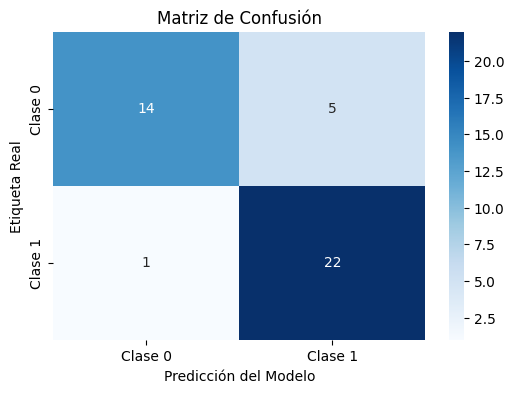

In [37]:
# Listas para guardar todas las predicciones y etiquetas reales
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
import seaborn as sns

todas_preds = []
todas_etiquetas = []

model.eval()
with torch.no_grad():
    for vinputs, vlabels in val_loader:
        probs = model(vinputs)
        preds = torch.round(probs)
        
        # Extraemos los datos de PyTorch (GPU/CPU) a listas de Python
        todas_preds.extend(preds.cpu().numpy())
        todas_etiquetas.extend(vlabels.view(-1, 1).float().cpu().numpy())

# Convertimos a formato unidimensional para Scikit-Learn
todas_preds = np.array(todas_preds).flatten()
todas_etiquetas = np.array(todas_etiquetas).flatten()

# --- CÁLCULO DE MÉTRICAS ---
acc = accuracy_score(todas_etiquetas, todas_preds)
prec = precision_score(todas_etiquetas, todas_preds)
rec = recall_score(todas_etiquetas, todas_preds)
f1 = f1_score(todas_etiquetas, todas_preds)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")

# --- MATRIZ DE CONFUSIÓN ---
cm = confusion_matrix(todas_etiquetas, todas_preds)

plt.figure(figsize=(6, 4))
# Usamos Seaborn para que la matriz quede bonita (ideal para trabajos)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Clase 0', 'Clase 1'], 
            yticklabels=['Clase 0', 'Clase 1'])
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción del Modelo')
plt.title('Matriz de Confusión')
plt.show()